# Eurasian Woodcock Call-Type Classification

Classify three call types (whistle, croak, chase) in Eurasian woodcock (*Scolopax rusticola*) recordings using BEATs and EfficientNet-B0 embeddings. Evaluation includes both a random split and a leave-one-deployment-out (LODO) cross-validation to test generalisation to unseen recording sites.

**Workflow:** download → explore → embed (BEATs last-layer, BEATs all-layers avg, EfficientNet) → UMAP → training-free metrics (NMI, ARI, R-AUC) → linear probe (random + LODO) → attention probe on sl-BEATs (random 80/20) → static + interactive figures → save artifacts.

In [1]:
import pathlib
import sys


def find_repo_root(start: pathlib.Path) -> pathlib.Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml not found).")


REPO_ROOT = find_repo_root(pathlib.Path().resolve())
sys.path.insert(0, str(REPO_ROOT))

import json
import urllib.request
import zipfile

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import soundfile as sf
import torch
from avex import load_model
from IPython.display import display
from tqdm.auto import tqdm

from utils.probing import compute_training_free_metrics, run_attention_probe
from utils.visualization import (
    horizontal_counts_bar_static,
    pivot_grouped_bar_static,
    plot_model_comparison,
    plot_model_comparison_static,
    plot_umap,
    plot_umap_static,
)

EXAMPLE_DIR = REPO_ROOT / "examples" / "08_woodcock_call_types"
DATA_DIR = EXAMPLE_DIR / "data"
AUDIO_DIR = DATA_DIR / "audio"
EMBED_DIR = DATA_DIR / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

ZENODO_BASE = "https://zenodo.org/records/10930931/files"
TARGET_SR = 16_000
DEVICE = "cpu"
BEATS_MODEL = "esp_aves2_sl_beats_all"
EFFNET_MODEL = "esp_aves2_effnetb0_all"
COLOR_MAP = {"whistle": "#2196F3", "croak": "#FF5722", "chase": "#4CAF50"}
CALL_TYPES = ["whistle", "croak", "chase"]
print("Setup complete.")

2026-04-16 17:00:29.962113: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-16 17:00:32.172387: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Setup complete.


## 1. Download Dataset

In [2]:
AUDIO_ARCHIVE = DATA_DIR / "selections_wavs.zip"
SELECTIONS_CSV = DATA_DIR / "selections.csv"

min_bytes = {"selections.csv": 1024, "selections_wavs.zip": 10 * 1024 * 1024}

for fname, path in [("selections.csv", SELECTIONS_CSV), ("selections_wavs.zip", AUDIO_ARCHIVE)]:
    ok = path.exists() and path.stat().st_size >= min_bytes[fname]
    if ok:
        print(f"{fname} present ({path.stat().st_size / 1e6:.0f} MB) — skipping.")
        continue
    if path.exists():
        path.unlink()

    def _hook(count, bs, total):
        if total > 0:
            print(f"\r  {min(count * bs / total * 100, 100):.1f}%", end="", flush=True)

    print(f"Downloading {fname} ...")
    urllib.request.urlretrieve(f"{ZENODO_BASE}/{fname}", path, reporthook=_hook)
    print(f"  Saved ({path.stat().st_size / 1e6:.0f} MB)")

EXTRACT_SENTINEL = AUDIO_DIR / ".extracted"
if not EXTRACT_SENTINEL.exists():
    AUDIO_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting audio ...")
    with zipfile.ZipFile(AUDIO_ARCHIVE) as zf:
        zf.extractall(AUDIO_DIR)
    EXTRACT_SENTINEL.touch()
    print("Done.")
else:
    print("Audio already extracted.")
print(f"WAV files: {len(list(AUDIO_DIR.rglob('*.wav')))}")

selections.csv present (0 MB) — skipping.
selections_wavs.zip present (559 MB) — skipping.
Audio already extracted.
WAV files: 2514


## 2. Data Exploration

In [3]:
df_raw = pd.read_csv(SELECTIONS_CSV)


def simplify_call_type(ann: str) -> str:
    ann = str(ann).lower()
    if "whistle" in ann:
        return "whistle"
    if "chase" in ann:
        return "chase"
    return "croak"


wav_files = sorted(AUDIO_DIR.rglob("*.wav"))
wav_lookup = {}
for p in wav_files:
    try:
        wav_lookup[int(p.stem)] = p
    except ValueError:
        pass

records = []
for _, row in df_raw.iterrows():
    selec_id = int(row["selec"])
    rec_base = pathlib.Path(str(row["sound.files"])).stem
    wav_path = wav_lookup.get(selec_id)
    records.append(
        {
            "selec": selec_id,
            "recording": rec_base,
            "deploy_id": row["deploy.id"],
            "start_s": row["start"],
            "end_s": row["end"],
            "duration_s": row["end"] - row["start"],
            "bottom_freq_khz": row["bottom.freq"],
            "top_freq_khz": row["top.freq"],
            "annotation_raw": row["annotation"],
            "call_type": simplify_call_type(row["annotation"]),
            "path": str(wav_path) if wav_path else "",
        }
    )

df = pd.DataFrame(records)
df = df[df["path"] != ""].reset_index(drop=True)
META_PATH = DATA_DIR / "metadata.csv"
df.to_csv(META_PATH, index=False)
print(f"Working set: {len(df)} selections")
display(df["call_type"].value_counts())

Working set: 2514 selections


call_type
whistle    2039
croak       459
chase        16
Name: count, dtype: int64

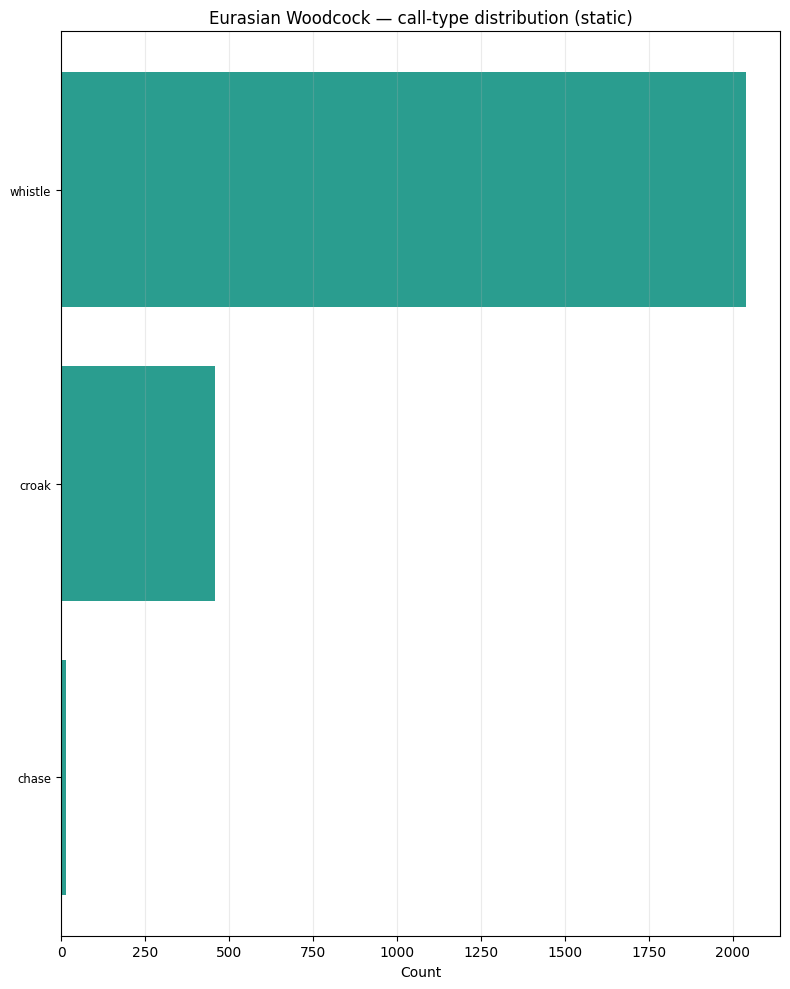

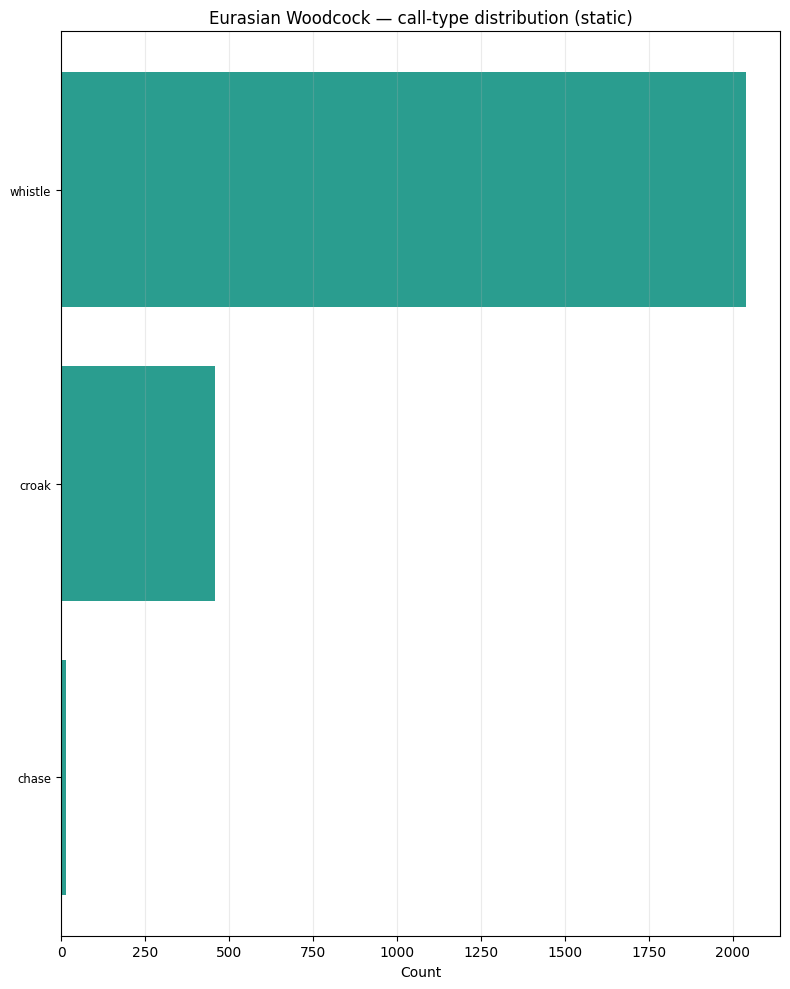

In [4]:
ct_counts = df["call_type"].value_counts().reset_index()
ct_counts.columns = ["call_type", "count"]
fig_dist = px.bar(
    ct_counts,
    x="call_type",
    y="count",
    color="call_type",
    color_discrete_map=COLOR_MAP,
    title="Eurasian Woodcock — call-type distribution",
    labels={"call_type": "Call type", "count": "Selections"},
    text="count",
)
fig_dist.update_traces(textposition="outside")
fig_dist.update_layout(showlegend=False)
fig_dist.show()
fig_dist_static = horizontal_counts_bar_static(
    ct_counts,
    x_col="count",
    y_col="call_type",
    title="Eurasian Woodcock — call-type distribution (static)",
)
display(fig_dist_static)

In [5]:
deploy_counts = df.groupby(["deploy_id", "call_type"]).size().reset_index(name="count")
deploy_order = df.groupby("deploy_id").size().sort_values(ascending=False).index.tolist()
fig_deploy = px.bar(
    deploy_counts,
    x="count",
    y="deploy_id",
    color="call_type",
    color_discrete_map=COLOR_MAP,
    orientation="h",
    category_orders={"deploy_id": deploy_order},
    title="Selections per deployment, coloured by call type",
    labels={"count": "Selections", "deploy_id": "Deployment"},
    height=600,
)
fig_deploy.show()
print(f"Total deployments: {df['deploy_id'].nunique()}")

Total deployments: 53


## 3. Embedding Extraction

In [6]:
def load_audio(path: str, target_sr: int = TARGET_SR) -> torch.Tensor:
    """Load a WAV, convert to mono, resample to target_sr, return (1, T) tensor."""
    wav, sr = sf.read(path, dtype="float32", always_2d=True)
    wav = wav.mean(axis=1)
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
    return torch.from_numpy(wav).unsqueeze(0)


print(f"Sample shape: {load_audio(df['path'].iloc[0]).shape}")

Sample shape: torch.Size([1, 48000])


In [7]:
BEATS_CACHE = EMBED_DIR / "beats_embeddings.npy"

if BEATS_CACHE.exists() and np.load(BEATS_CACHE).shape[0] == len(df):
    beats_embs = np.load(BEATS_CACHE)
    print(f"Loaded cached BEATs last-layer embeddings: {beats_embs.shape}")
else:
    print(f"Loading model: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs last-layer"):
            wav = load_audio(path)
            feats = model(wav)  # (1, T, 768)
            embeddings.append(feats.mean(dim=1).squeeze(0).cpu().numpy())
    beats_embs = np.stack(embeddings)
    np.save(BEATS_CACHE, beats_embs)
    print(f"Saved BEATs last-layer embeddings: {beats_embs.shape}")
    del model

Loaded cached BEATs last-layer embeddings: (2514, 768)


In [8]:
BEATS_ALL_CACHE = EMBED_DIR / "beats_all_layers_embeddings.npy"

if BEATS_ALL_CACHE.exists() and np.load(BEATS_ALL_CACHE).shape[0] == len(df):
    beats_all_embs = np.load(BEATS_ALL_CACHE)
    print(f"Loaded cached BEATs all-layers embeddings: {beats_all_embs.shape}")
else:
    print(f"Loading model for all-layers extraction: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()

    # Register forward hooks on every transformer encoder layer
    try:
        encoder_layers = model.model.encoder.layers
    except AttributeError:
        encoder_layers = model.backbone.encoder.layers
    n_layers = len(encoder_layers)
    layer_store: dict = {}
    hooks = []
    for i, layer in enumerate(encoder_layers):

        def _make_hook(idx):
            def _hook(module, inp, out):
                layer_store[idx] = out[0] if isinstance(out, tuple) else out

            return _hook

        hooks.append(layer.register_forward_hook(_make_hook(i)))
    print(f"  Registered hooks on {n_layers} transformer layers.")

    all_embs = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs all-layers"):
            layer_store.clear()
            wav = load_audio(path)
            _ = model(wav)
            # Mean-pool each layer then average across layers → (D,)
            # Handles both time-first (T, B, D) and batch-first (B, T, D) outputs
            per_layer = [
                layer_store[i].view(-1, layer_store[i].shape[-1]).mean(dim=0).cpu().numpy() for i in range(n_layers)
            ]
            all_embs.append(np.mean(per_layer, axis=0))

    for h in hooks:
        h.remove()

    beats_all_embs = np.stack(all_embs)
    np.save(BEATS_ALL_CACHE, beats_all_embs)
    print(f"Saved BEATs all-layers embeddings: {beats_all_embs.shape}")
    del model

Loaded cached BEATs all-layers embeddings: (2514, 768)


In [9]:
EFFNET_CACHE = EMBED_DIR / "effnet_embeddings.npy"

if EFFNET_CACHE.exists() and np.load(EFFNET_CACHE).shape[0] == len(df):
    effnet_embs = np.load(EFFNET_CACHE)
    print(f"Loaded cached EfficientNet embeddings: {effnet_embs.shape}")
else:
    print(f"Loading model: {EFFNET_MODEL}")
    model = load_model(EFFNET_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="EfficientNet"):
            wav = load_audio(path)
            feats = model(wav)  # (1, C, H, W)
            embeddings.append(feats.mean(dim=(2, 3)).squeeze(0).cpu().numpy())
    effnet_embs = np.stack(embeddings)
    np.save(EFFNET_CACHE, effnet_embs)
    print(f"Saved EfficientNet embeddings: {effnet_embs.shape}")
    del model

Loaded cached EfficientNet embeddings: (2514, 1280)


## 4. UMAP Visualisation

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


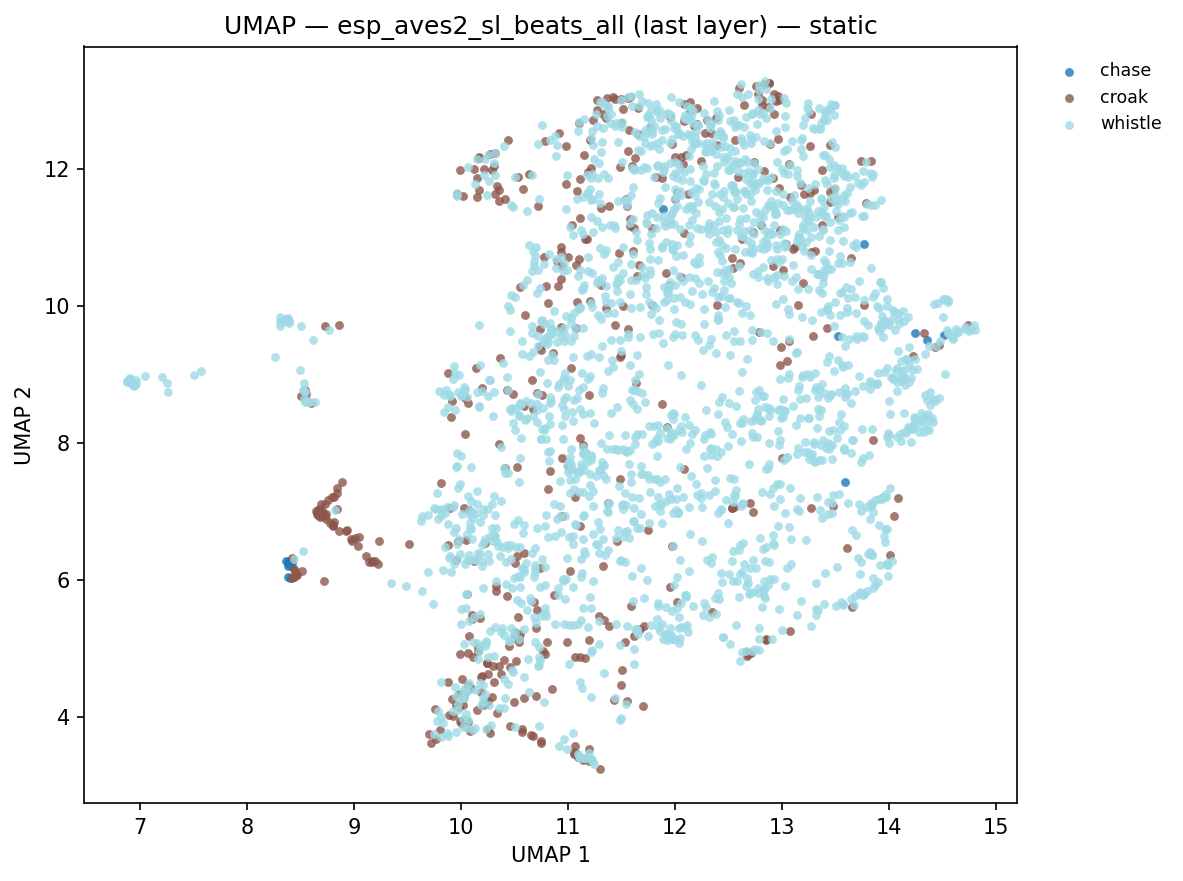

In [10]:
labels = df["call_type"].tolist()
hover = [
    f"{row['path'].split('/')[-1]}<br>Type: {row['call_type']}<br>Deploy: {row['deploy_id']}"
    for _, row in df.iterrows()
]

fig_beats = plot_umap(
    beats_embs,
    labels=labels,
    title=f"UMAP — {BEATS_MODEL} (last layer)<br><sup>colour = call type</sup>",
    hover_text=hover,
)
fig_beats.show()
fig_umap_beats_static = plot_umap_static(beats_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (last layer) — static")
display(fig_umap_beats_static)

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


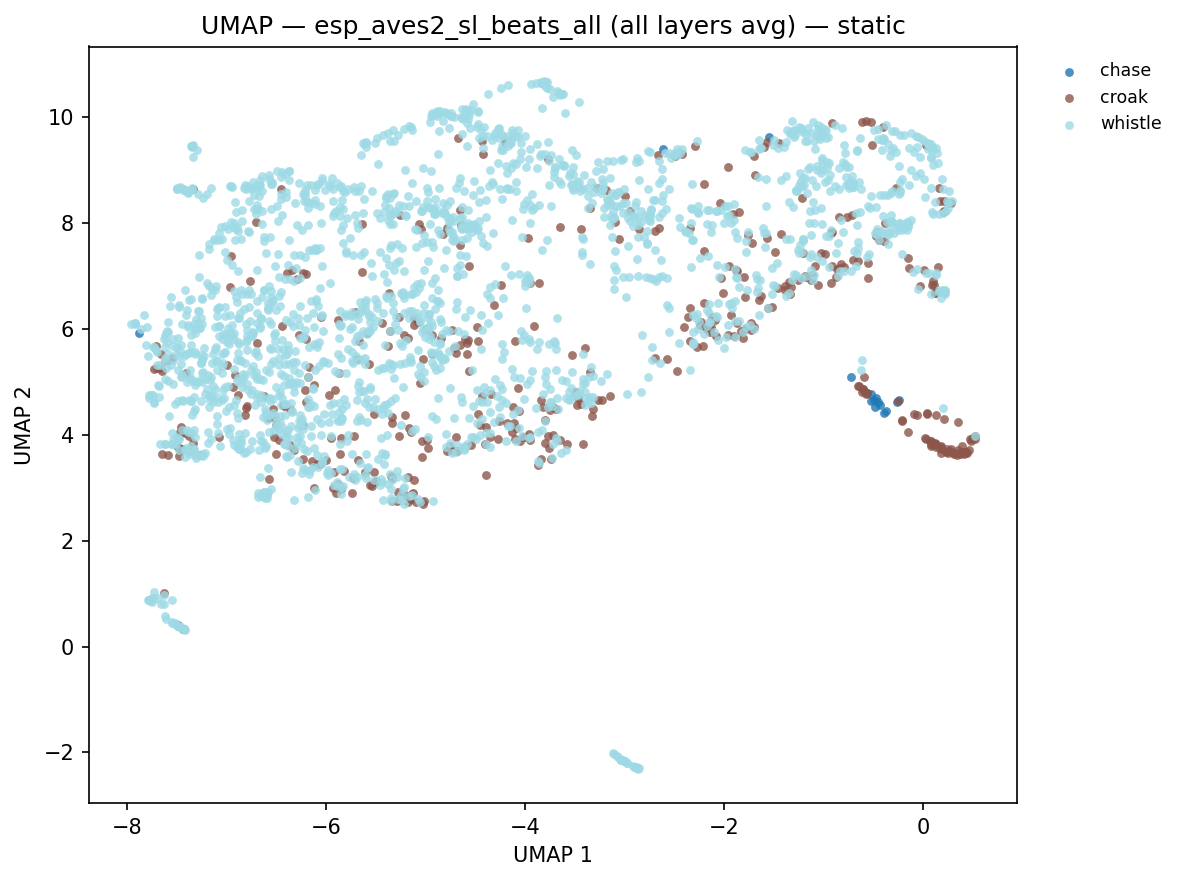

In [11]:
fig_beats_all = plot_umap(
    beats_all_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (all layers avg)", hover_text=hover
)
fig_beats_all.show()
fig_umap_beats_all_static = plot_umap_static(
    beats_all_embs, labels=labels, title=f"UMAP — {BEATS_MODEL} (all layers avg) — static"
)
display(fig_umap_beats_all_static)

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


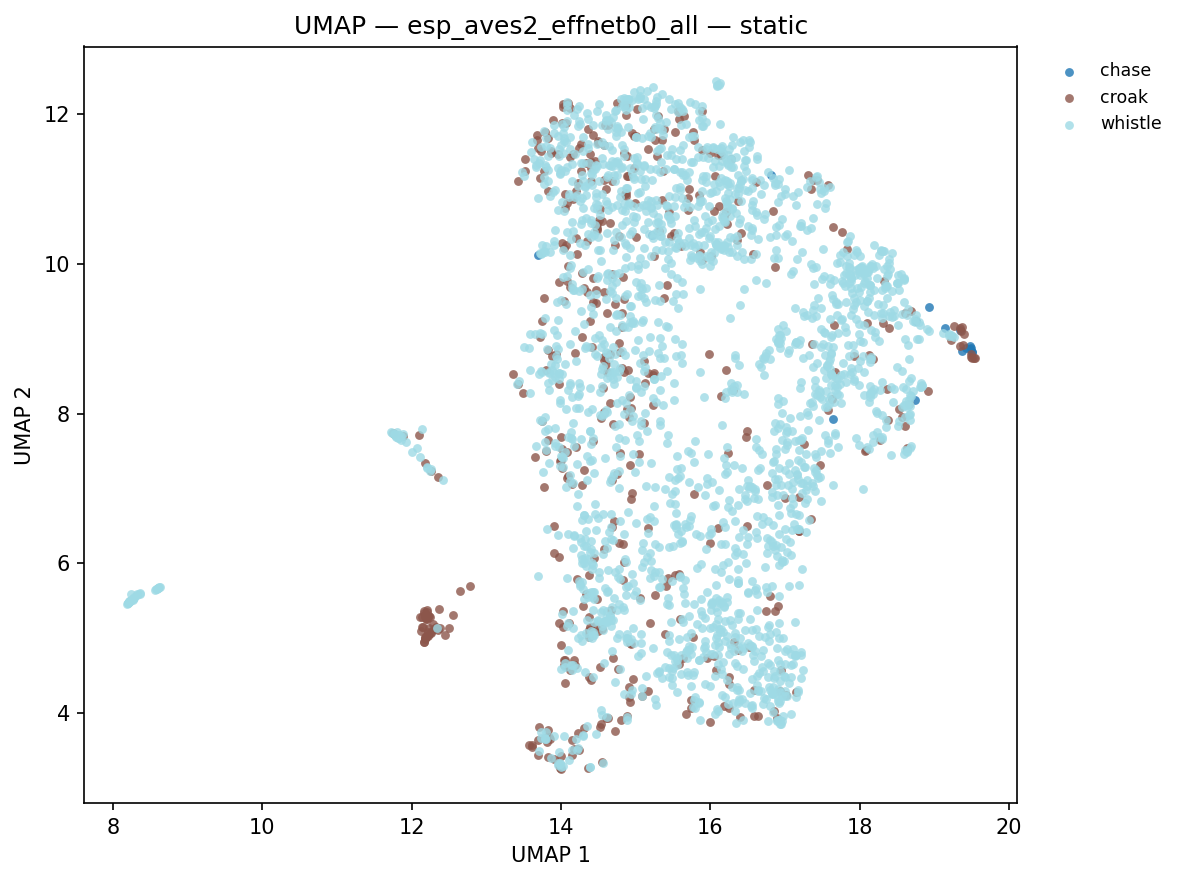

In [12]:
fig_effnet = plot_umap(effnet_embs, labels=labels, title=f"UMAP — {EFFNET_MODEL}", hover_text=hover)
fig_effnet.show()
fig_umap_effnet_static = plot_umap_static(effnet_embs, labels=labels, title=f"UMAP — {EFFNET_MODEL} — static")
display(fig_umap_effnet_static)

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


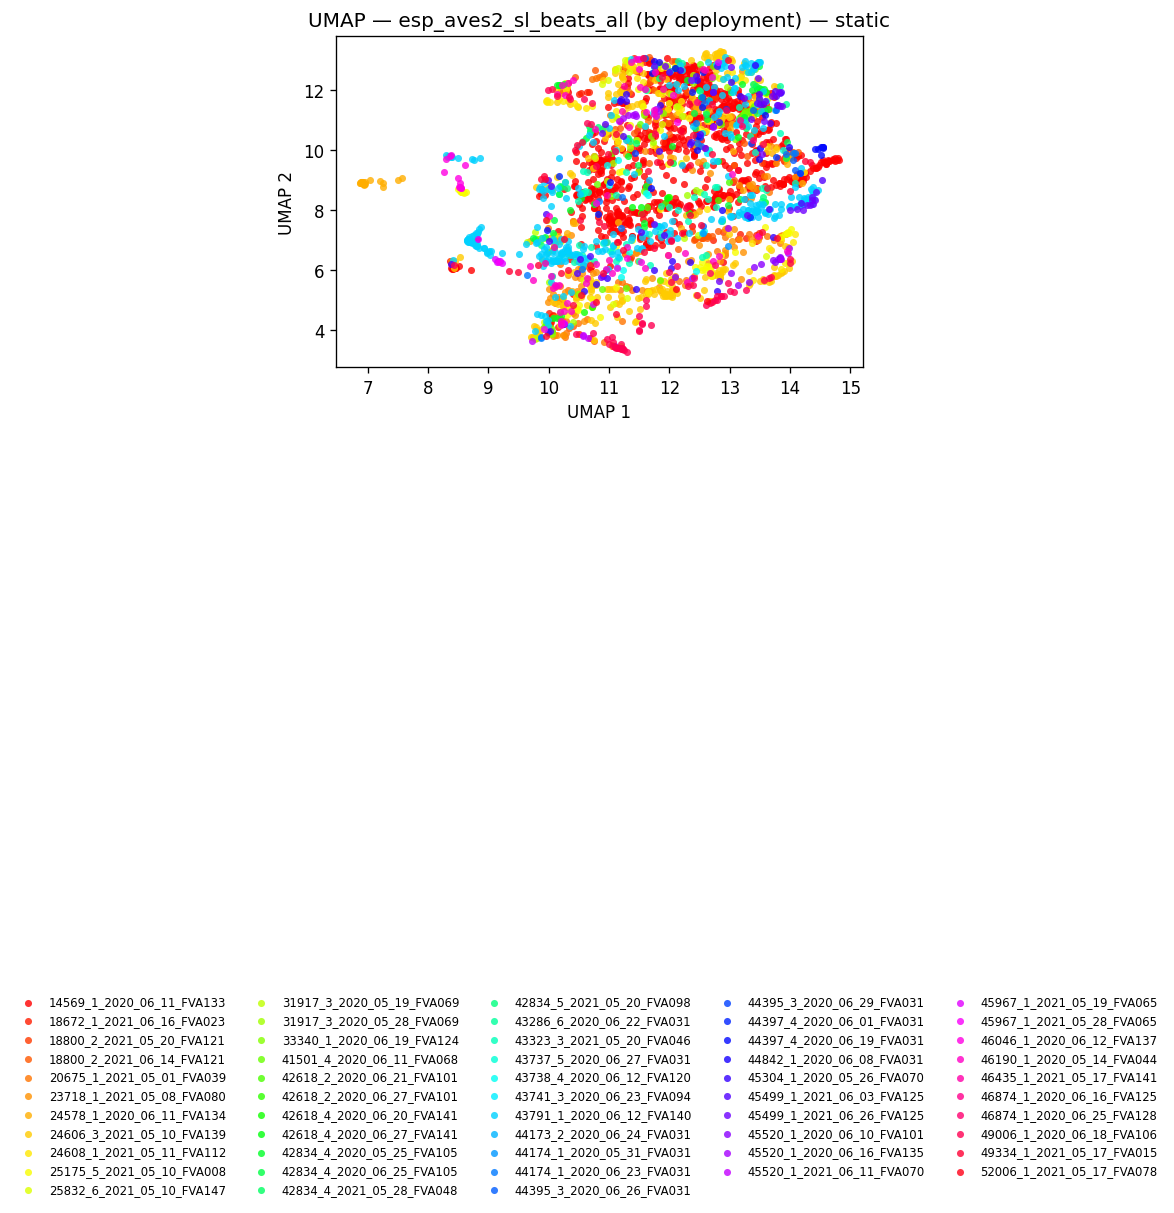

In [13]:
deploy_labels = df["deploy_id"].tolist()
fig_deploy_umap = plot_umap(
    beats_embs,
    labels=deploy_labels,
    title=f"UMAP — {BEATS_MODEL}<br><sup>colour = deployment site</sup>",
    hover_text=hover,
)
fig_deploy_umap.show()
fig_umap_deploy_static = plot_umap_static(
    beats_embs, labels=deploy_labels, title=f"UMAP — {BEATS_MODEL} (by deployment) — static"
)
display(fig_umap_deploy_static)

## 5. Training-Free Metrics

Computed on the full embedding set using call type as the target label. These require no classifier training.

In [14]:
print("Computing training-free metrics (NMI, ARI, R-AUC) ...")
print("These evaluate embedding quality without fitting any classifier.\n")

_labels_for_metrics = labels

_metric_models = [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]

_metric_rows = []
for _name, _embs in _metric_models:
    _m = compute_training_free_metrics(_embs, _labels_for_metrics)
    _metric_rows.append(
        {"Model": _name, "NMI": round(_m["nmi"], 3), "ARI": round(_m["ari"], 3), "R-AUC": round(_m["r_auc"], 3)}
    )
    print(f"  {_name}: NMI={_m['nmi']:.3f}  ARI={_m['ari']:.3f}  R-AUC={_m['r_auc']:.3f}")

_metrics_df = pd.DataFrame(_metric_rows).set_index("Model")
display(_metrics_df)

Computing training-free metrics (NMI, ARI, R-AUC) ...
These evaluate embedding quality without fitting any classifier.



  esp_aves2_sl_beats_all (last layer): NMI=0.030  ARI=0.021  R-AUC=0.719


  esp_aves2_sl_beats_all (all layers avg): NMI=0.024  ARI=0.000  R-AUC=0.735


  esp_aves2_effnetb0_all: NMI=0.016  ARI=-0.004  R-AUC=0.723


,NMI,ARI,R-AUC
Model,,,
esp_aves2_sl_beats_all (last layer),0.030,0.021,0.719
esp_aves2_sl_beats_all (all layers avg),0.024,0.000,0.735
esp_aves2_effnetb0_all,0.016,-0.004,0.723


## 6. Linear Probe

Two evaluation protocols:
- **Random split** (80/20 stratified): standard baseline
- **Leave-one-deployment-out (LODO)**: tests generalisation to unseen recording sites

Balanced accuracy is used because *whistle* accounts for ~79% of samples.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import LeaveOneGroupOut, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

from utils.probing import _balanced_accuracy_from_confusion_matrix

deploy_ids = df["deploy_id"].values
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(beats_embs, labels))

random_results = {}
for emb_name, embs in [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]:
    X_tr, X_te = embs[train_idx], embs[test_idx]
    y_tr = np.array(labels)[train_idx]
    y_te = np.array(labels)[test_idx]
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    clf = LogisticRegression(max_iter=2000, random_state=42, solver="lbfgs")
    clf.fit(X_tr_sc, y_tr)
    y_pred = clf.predict(X_te_sc)
    all_labels = np.array(sorted(set(labels)))
    cm = confusion_matrix(y_te, y_pred, labels=all_labels)
    bal_acc = _balanced_accuracy_from_confusion_matrix(cm)
    random_results[emb_name] = {"balanced_accuracy": bal_acc, "y_te": y_te, "y_pred": y_pred}
    print(f"{emb_name}: balanced_accuracy = {bal_acc:.3f}")

esp_aves2_sl_beats_all (last layer): balanced_accuracy = 0.696


esp_aves2_sl_beats_all (all layers avg): balanced_accuracy = 0.601


esp_aves2_effnetb0_all: balanced_accuracy = 0.821


### Attention probe on sl-BEATs (random 80/20)

Same train/test protocol as the logistic baseline above (`test_size=0.2`, `random_state=42`), using `avex.models.probes.AttentionProbe` in feature mode on mean-pooled embeddings.

esp_aves2_sl_beats_all (last layer) (attention, 80/20): balanced_accuracy = 0.445


esp_aves2_sl_beats_all (all layers avg) (attention, 80/20): balanced_accuracy = 0.467


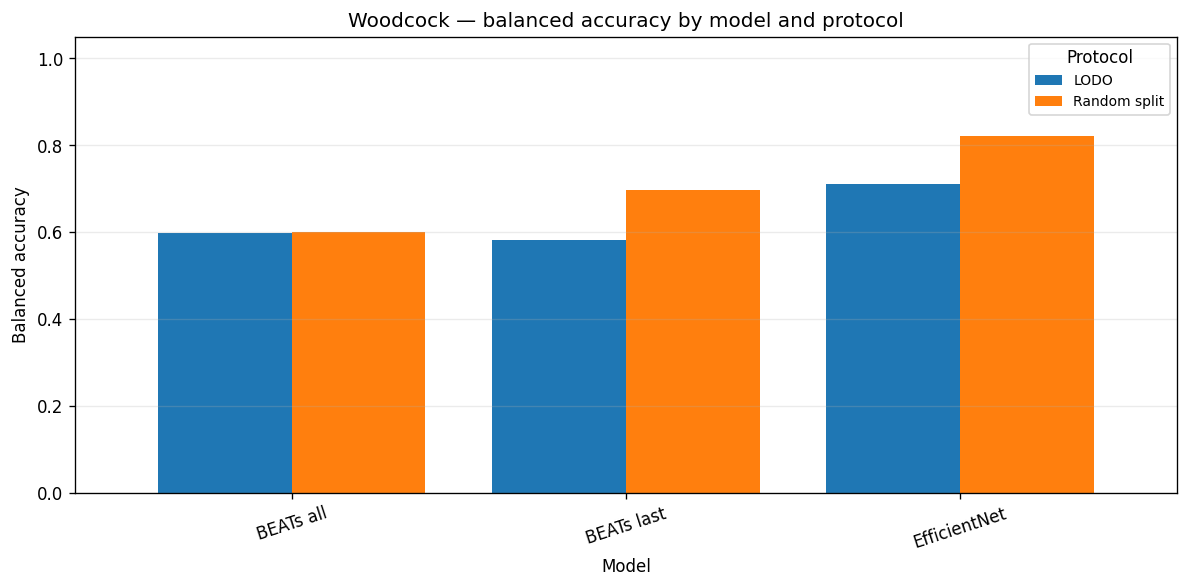

In [16]:
from sklearn.metrics import balanced_accuracy_score

attention_random_results = {}
for emb_name, embs in [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
]:
    res = run_attention_probe(
        embs,
        labels,
        num_heads=8,
        num_attn_layers=2,
        epochs=50,
        test_size=0.2,
        random_state=42,
    )
    if len(res["y_pred"]) == 0:
        ba = float("nan")
    else:
        ba = float(balanced_accuracy_score(res["y_test"], res["y_pred"]))
    attention_random_results[emb_name] = {"balanced_accuracy": ba}
    print(f"{emb_name} (attention, 80/20): balanced_accuracy = {ba:.3f}")

In [17]:
# Leave-one-deployment-out evaluation
logo = LeaveOneGroupOut()
lodo_results = {}

for emb_name, embs in [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]:
    fold_scores = []
    all_y_true, all_y_pred = [], []
    for tr_idx, te_idx in logo.split(embs, labels, groups=deploy_ids):
        X_tr, X_te = embs[tr_idx], embs[te_idx]
        y_tr = np.array(labels)[tr_idx]
        y_te = np.array(labels)[te_idx]
        if len(np.unique(y_te)) < 2:
            continue
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)
        clf = LogisticRegression(max_iter=2000, random_state=42, solver="lbfgs")
        clf.fit(X_tr_sc, y_tr)
        y_pred = clf.predict(X_te_sc)
        all_labels = np.array(sorted(set(labels)))
        cm = confusion_matrix(y_te, y_pred, labels=all_labels)
        fold_scores.append(_balanced_accuracy_from_confusion_matrix(cm))
        all_y_true.extend(y_te)
        all_y_pred.extend(y_pred)
    mean_ba = float(np.mean(fold_scores))
    std_ba = float(np.std(fold_scores))
    lodo_results[emb_name] = {
        "fold_scores": fold_scores,
        "mean_bal_acc": mean_ba,
        "std_bal_acc": std_ba,
        "y_true": all_y_true,
        "y_pred": all_y_pred,
    }
    print(f"{emb_name}: LODO balanced_accuracy = {mean_ba:.3f} ± {std_ba:.3f}  (n_folds={len(fold_scores)})")

/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


esp_aves2_sl_beats_all (last layer): LODO balanced_accuracy = 0.582 ± 0.211  (n_folds=28)


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


esp_aves2_sl_beats_all (all layers avg): LODO balanced_accuracy = 0.598 ± 0.177  (n_folds=28)


/home/marius_miron_earthspecies_org/code/avex-examples/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


esp_aves2_effnetb0_all: LODO balanced_accuracy = 0.710 ± 0.173  (n_folds=28)


,Random split (balanced acc),LODO (mean balanced acc),LODO (std)
Model,,,
esp_aves2_sl_beats_all (last layer),0.696,0.582,0.211
esp_aves2_sl_beats_all (all layers avg),0.601,0.598,0.177
esp_aves2_effnetb0_all,0.821,0.710,0.173


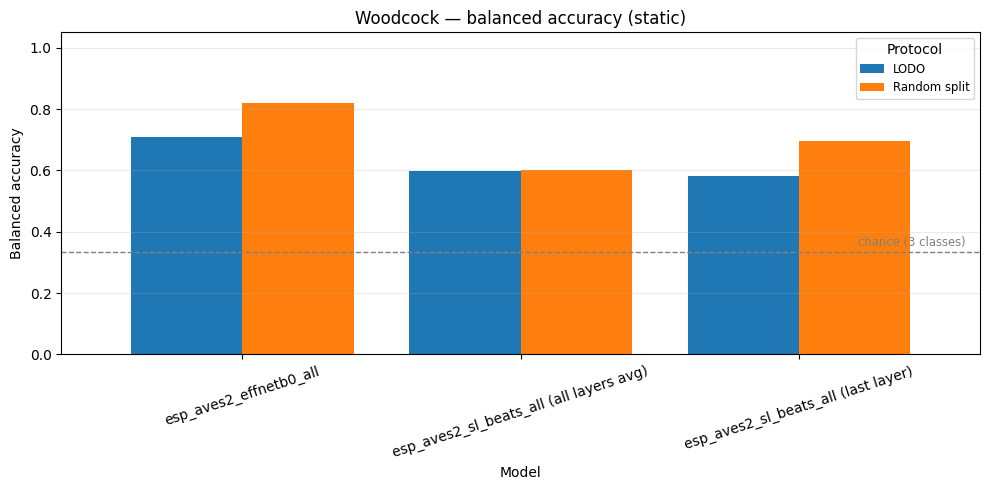

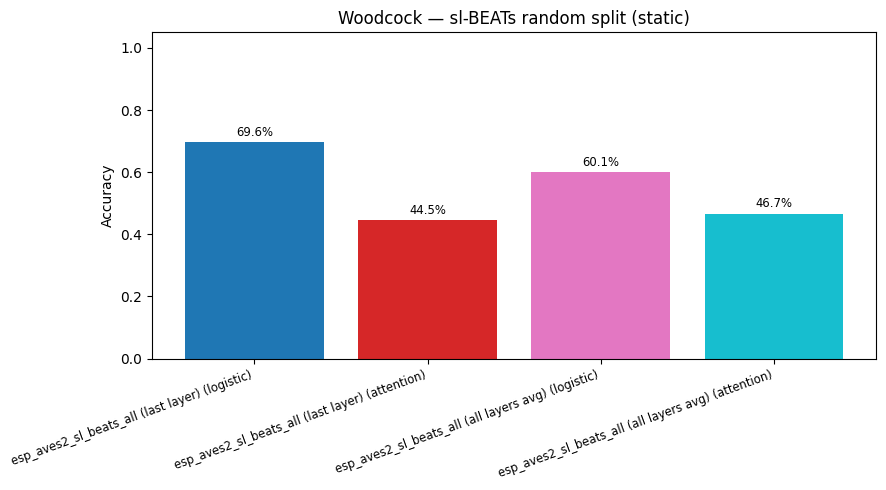

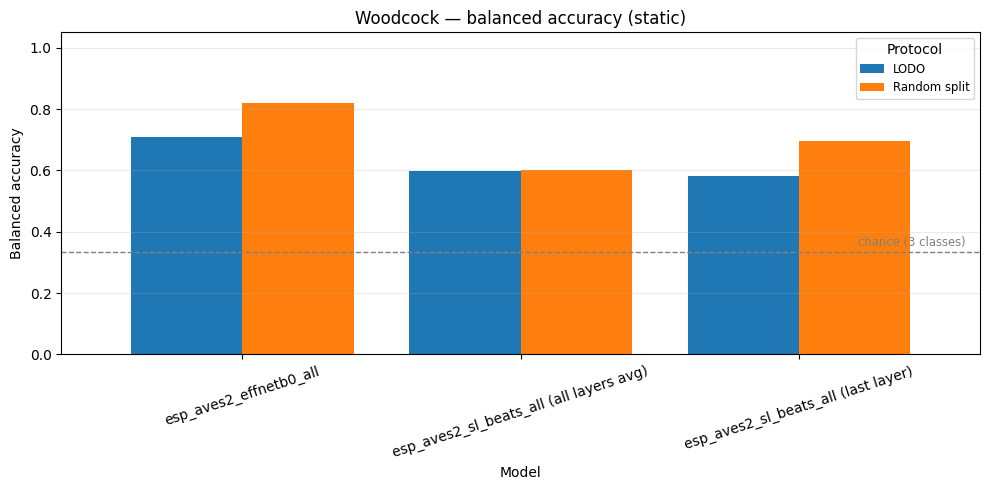

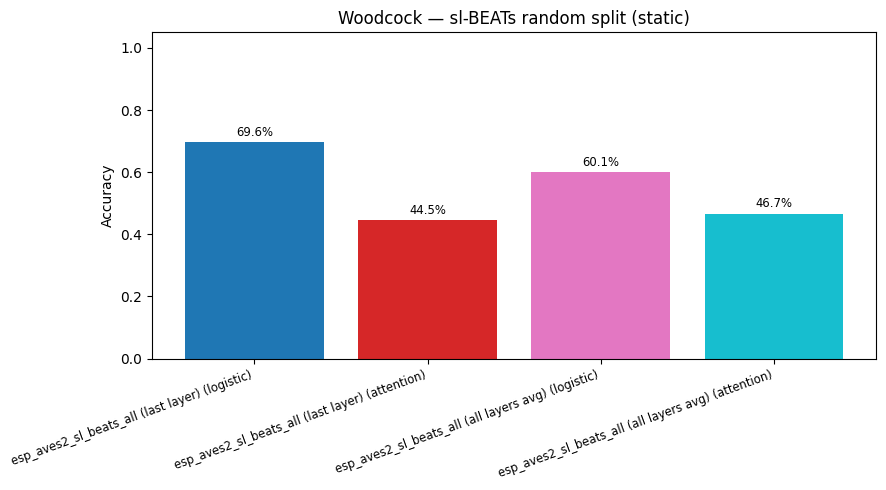

In [18]:
summary_rows = []
for emb_name in random_results:
    summary_rows.append(
        {
            "Model": emb_name,
            "Random split (balanced acc)": round(random_results[emb_name]["balanced_accuracy"], 3),
            "LODO (mean balanced acc)": round(lodo_results[emb_name]["mean_bal_acc"], 3),
            "LODO (std)": round(lodo_results[emb_name]["std_bal_acc"], 3),
        }
    )
summary_df = pd.DataFrame(summary_rows).set_index("Model")
display(summary_df)

bar_data = []
for row in summary_rows:
    bar_data.append(
        {"Model": row["Model"], "Protocol": "Random split", "Balanced accuracy": row["Random split (balanced acc)"]}
    )
    bar_data.append({"Model": row["Model"], "Protocol": "LODO", "Balanced accuracy": row["LODO (mean balanced acc)"]})
bar_df = pd.DataFrame(bar_data)
fig_cmp = px.bar(
    bar_df,
    x="Model",
    y="Balanced accuracy",
    color="Protocol",
    barmode="group",
    title="Woodcock: BEATs vs EfficientNet — balanced accuracy",
    text="Balanced accuracy",
)
fig_cmp.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_cmp.add_hline(y=1 / 3, line_dash="dot", annotation_text="random baseline", line_color="grey")
fig_cmp.update_layout(yaxis_range=[0, 1.05])
fig_cmp.show()

fig_cmp_static = pivot_grouped_bar_static(
    bar_df,
    index="Model",
    columns="Protocol",
    values="Balanced accuracy",
    title="Woodcock — balanced accuracy (static)",
    ylabel="Balanced accuracy",
    hline_y=1 / 3,
    hline_label="chance (3 classes)",
)
display(fig_cmp_static)

beats_attn_cmp = {}
for base in [f"{BEATS_MODEL} (last layer)", f"{BEATS_MODEL} (all layers avg)"]:
    beats_attn_cmp[f"{base} (logistic)"] = random_results[base]["balanced_accuracy"]
    beats_attn_cmp[f"{base} (attention)"] = attention_random_results[base]["balanced_accuracy"]
fig_beats_attn = plot_model_comparison(
    beats_attn_cmp,
    title="Woodcock — sl-BEATs random split: logistic vs attention (balanced acc)",
)
fig_beats_attn.show()
display(
    plot_model_comparison_static(
        beats_attn_cmp,
        title="Woodcock — sl-BEATs random split (static)",
    )
)

## 7. Save Artifacts

In [19]:
ARTIFACTS_DIR = EXAMPLE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

fig_beats.write_html(str(ARTIFACTS_DIR / "umap_beats.html"))
fig_beats_all.write_html(str(ARTIFACTS_DIR / "umap_beats_all_layers.html"))
fig_effnet.write_html(str(ARTIFACTS_DIR / "umap_effnet.html"))
fig_deploy_umap.write_html(str(ARTIFACTS_DIR / "umap_beats_by_deployment.html"))
fig_dist.write_html(str(ARTIFACTS_DIR / "call_type_distribution.html"))
fig_cmp.write_html(str(ARTIFACTS_DIR / "balanced_accuracy.html"))
fig_beats_attn.write_html(str(ARTIFACTS_DIR / "balanced_accuracy_beats_attn.html"))

fig_dist_static.savefig(str(ARTIFACTS_DIR / "call_type_distribution_static.png"), dpi=150, bbox_inches="tight")
fig_umap_beats_static.savefig(str(ARTIFACTS_DIR / "umap_beats_static.png"), dpi=150, bbox_inches="tight")
fig_umap_beats_all_static.savefig(str(ARTIFACTS_DIR / "umap_beats_all_layers_static.png"), dpi=150, bbox_inches="tight")
fig_umap_effnet_static.savefig(str(ARTIFACTS_DIR / "umap_effnet_static.png"), dpi=150, bbox_inches="tight")
fig_umap_deploy_static.savefig(str(ARTIFACTS_DIR / "umap_beats_by_deployment_static.png"), dpi=150, bbox_inches="tight")
plt.close("all")

_metrics_out = {
    "n_rows": len(df),
    "class_counts": df["call_type"].value_counts().to_dict(),
    "training_free": {
        k: compute_training_free_metrics(v, labels)
        for k, v in [("beats_last", beats_embs), ("beats_all_layers", beats_all_embs), ("effnet", effnet_embs)]
    },
}
for emb_name, res in random_results.items():
    safe_key = emb_name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    _metrics_out.setdefault("random_split", {})[safe_key] = {"balanced_accuracy": round(res["balanced_accuracy"], 4)}
for emb_name, res in attention_random_results.items():
    safe_key = emb_name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    _metrics_out.setdefault("attention_random_split", {})[safe_key] = {
        "balanced_accuracy": round(res["balanced_accuracy"], 4)
    }
for emb_name, res in lodo_results.items():
    safe_key = emb_name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    _metrics_out.setdefault("lodo", {})[safe_key] = {
        "n_folds": len(res["fold_scores"]),
        "mean_balanced_accuracy": round(res["mean_bal_acc"], 4),
        "std_balanced_accuracy": round(res["std_bal_acc"], 4),
    }
with open(ARTIFACTS_DIR / "woodcock_metrics.json", "w") as _f:
    json.dump(_metrics_out, _f, indent=2)
print(f"Artifacts saved to {ARTIFACTS_DIR}")

Artifacts saved to /home/marius_miron_earthspecies_org/code/avex-examples/examples/08_woodcock_call_types/artifacts
